# Demo
This notebook aims to demo some functionality for new members onboarding

In [7]:
%load_ext autoreload
%autoreload 2

## Remote simulator

In [ ]:
from config_loader import CONFIG
from remote import PS5Remote, RemoteSimulator
from logger import Logger, LogLevels

remote = PS5Remote(Logger(identifier="remote"))
simulator = RemoteSimulator(remote)
simulator.run()
print("Simulation is running on a separate window")

ImportError: cannot import name 'PS5Remote' from 'remote' (unknown location)

# Planification des taches

## Optimisation des tâches

### Algorithme

Considérons un problème d'optimisation combinatoire appliqué à la planification de tâches d'un robot mobile. Le problème se définit ainsi : étant donné un ensemble de $n$ tâches, une position initiale $p_0$ et une position finale $p_f$, nous cherchons à déterminer une séquence optimale de tâches à exécuter. Chaque tâche est caractérisée par trois paramètres : un score $s$, un temps d'exécution $t_e$, et une position terminale $p$ dans l'espace de travail du robot. Le temps de déplacement $t_t$ entre deux positions successives est calculé via une fonction $f: \mathbb{R}^2 \times \mathbb{R}^2 \rightarrow \mathbb{R}$ qui associe à deux positions $p_a$ et $p_b$ un temps $t$.

Reformulons ce problème :

Soit $G=(V,E)$ un graphe complet pondéré où chaque arête $(u,v)∈E$ est associée à un coût $c_d(u,v)\in ℕ$. De plus, chaque sommet $v∈V$ possède deux attributs : un score $s(v)$ et un coût $c_t(v)$.

L'objectif est de déterminer un chemin $v_0$→$v_f$, maximisant la somme des scores des sommets visités, tout en respectant une contrainte de coût total. Plus précisément, la somme des coûts des sommets et des arêtes parcourus, définie comme :

$$
C = \sum_{(u,v) \in E'} c_d(u,v) + \sum_{v \in V'} c_t(v)
$$

doit être inférieure ou égale à un seuil $M$, où $E'$ et $V'$ représentent respectivement les arêtes et les sommets de la chaine sélectionnée.

In [3]:
from config_loader import CONFIG
from tasks import Task
from brains import MainBrain

23:58:39.015125 -> [GridMan..] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
23:58:39.248919 -> [GridMan..] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).
23:58:39.357759 -> [DictPro..] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
23:58:39.431964 -> [DictPro..] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).


### Demo

19:42:37.855398 -> [  WSmsg  ] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
19:42:38.012509 -> [  WSmsg  ] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).
19:42:38.016876 -> [WSrecei..] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
19:42:38.216571 -> [WSrecei..] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).
19:42:38.224119 -> [ WSender ] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
19:42:38.381859 -> [ WSender ] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).
19:42:38.386752 -> [WSclien..] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
19:42:38.529921 -> [WSclien..] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).
19:42:38.529921 -> [ WSclient] [monitoring..:175]    INFO    | === Logs Cleaning Info ===
19:42:38.687943 -> [ WSclient] [monitoring..:185]    INFO    | Log size within limits (0.01Go/1.0Go).
19:42:38.944037 -> [WServer..] [monitori

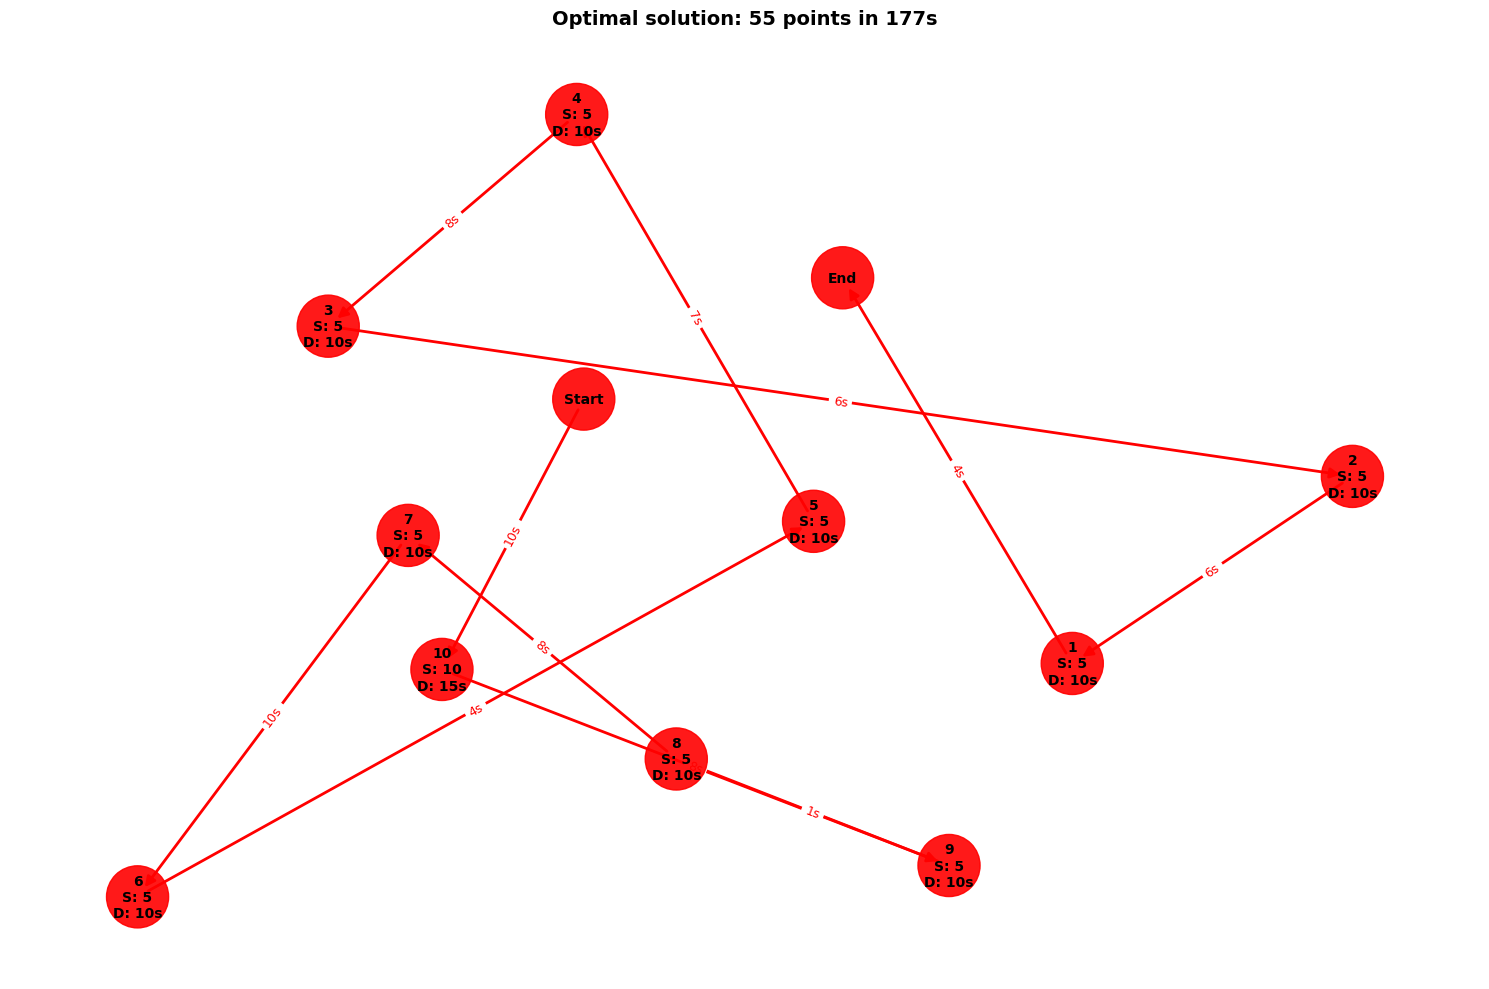

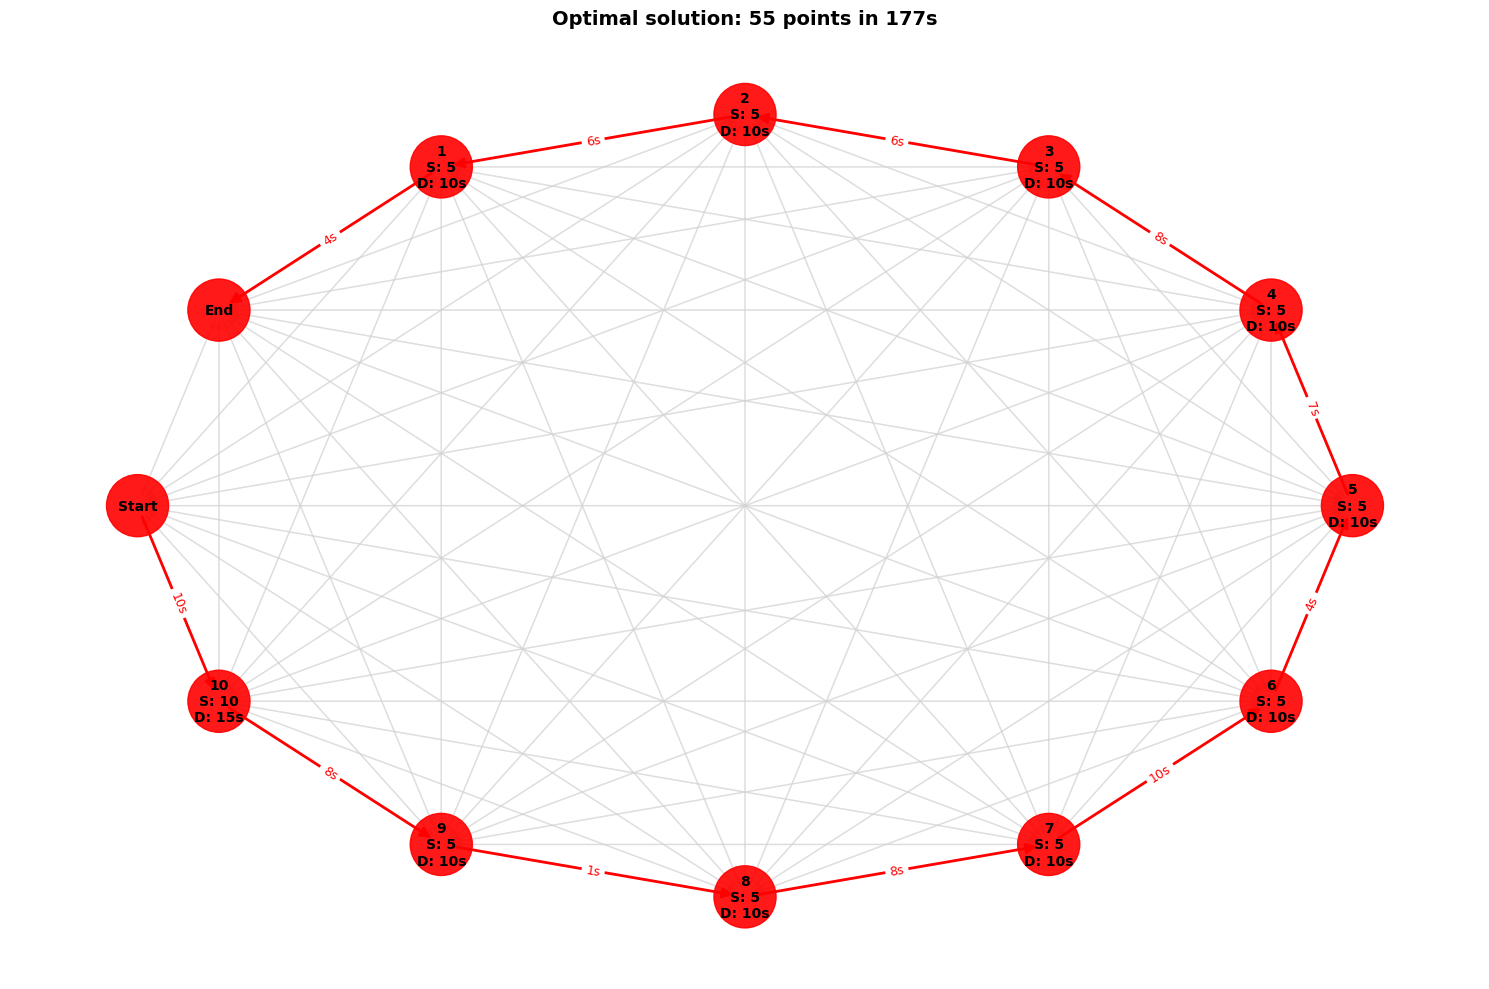

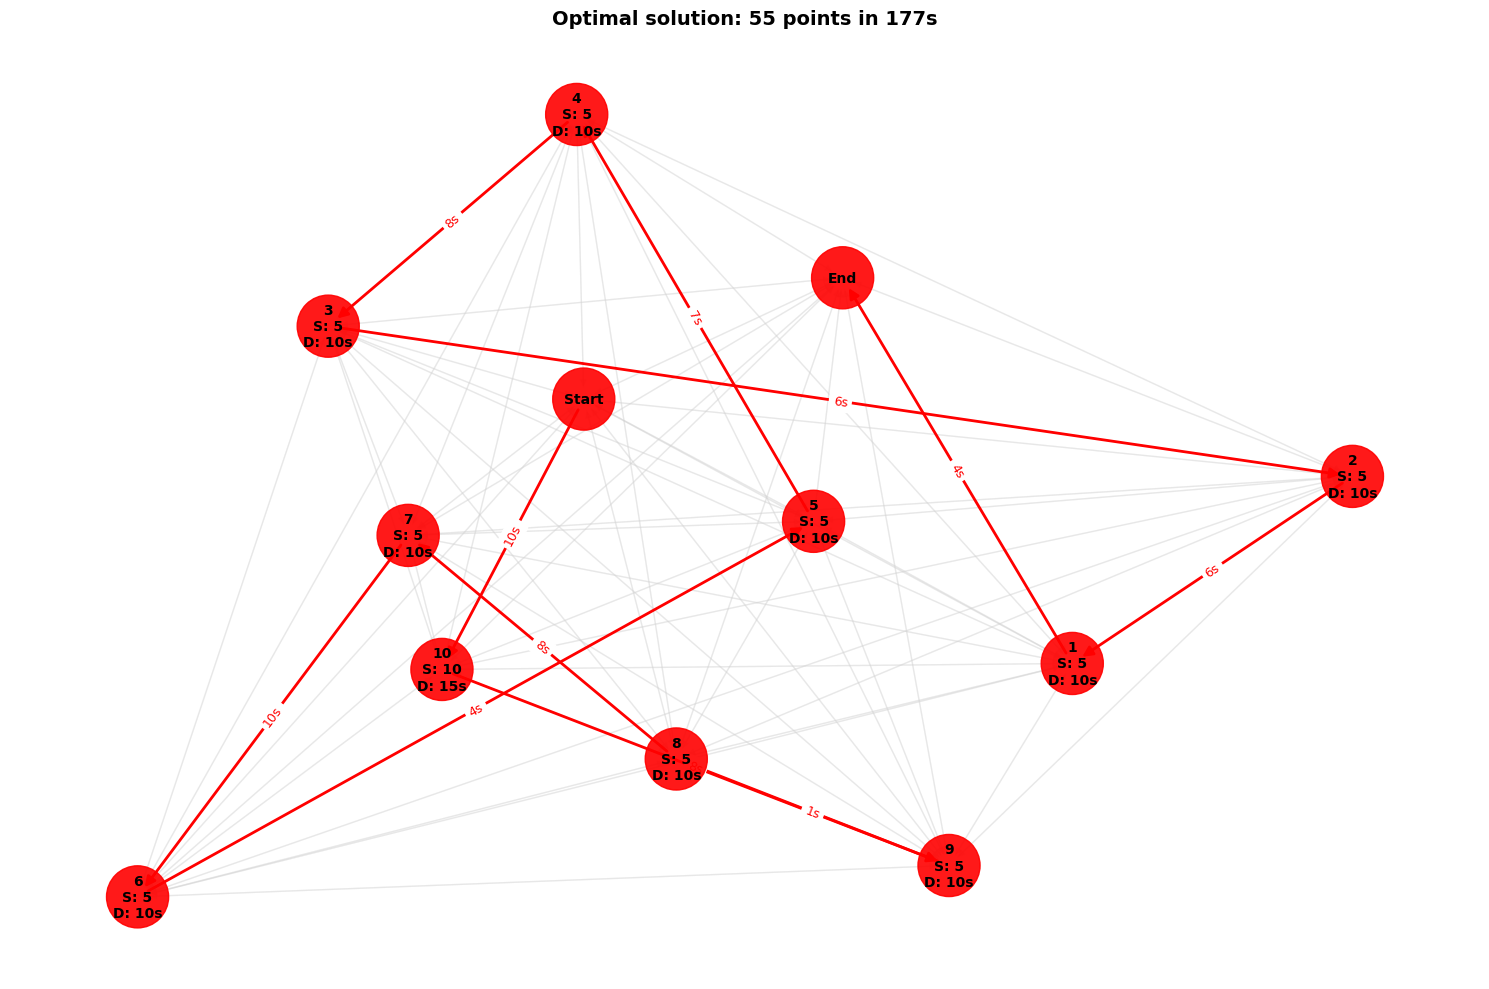

19:42:54.404400 -> [ Dummy Arena ] [  arena.py  :107]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
19:42:54.405468 -> [ Dummy Arena ] [  arena.py  :113]  WARNING   | The obstacle buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
19:42:54.605572 -> [ Dummy Grid Manager ] [decorators.py:41]   DEBUG    | [grid_manager] GridManager.__mark_zone(self=<arena.base_..., grid=<Grid width=..., polygon_to_mark=<POLYGON ((1..., walkable=False) executed in 0.081124s
19:42:54.608289 -> [ Dummy Grid Manager ] [decorators.py:41]   DEBUG    | [arena] GridManager.add_forbidden_static_zone(self=<arena.base_..., forbidden_zones=<POLYGON ((1...) executed in 0.083256s
19:42:54.698653 -> [ Dummy Grid Manager ] [decorators.py:41]   DEBUG    | [grid_manager] GridManager.__mark_zone(self=<arena.base_..., grid=<Grid width=..., polygon_to_mark=<POLYGON ((1..., walkable=False) execute

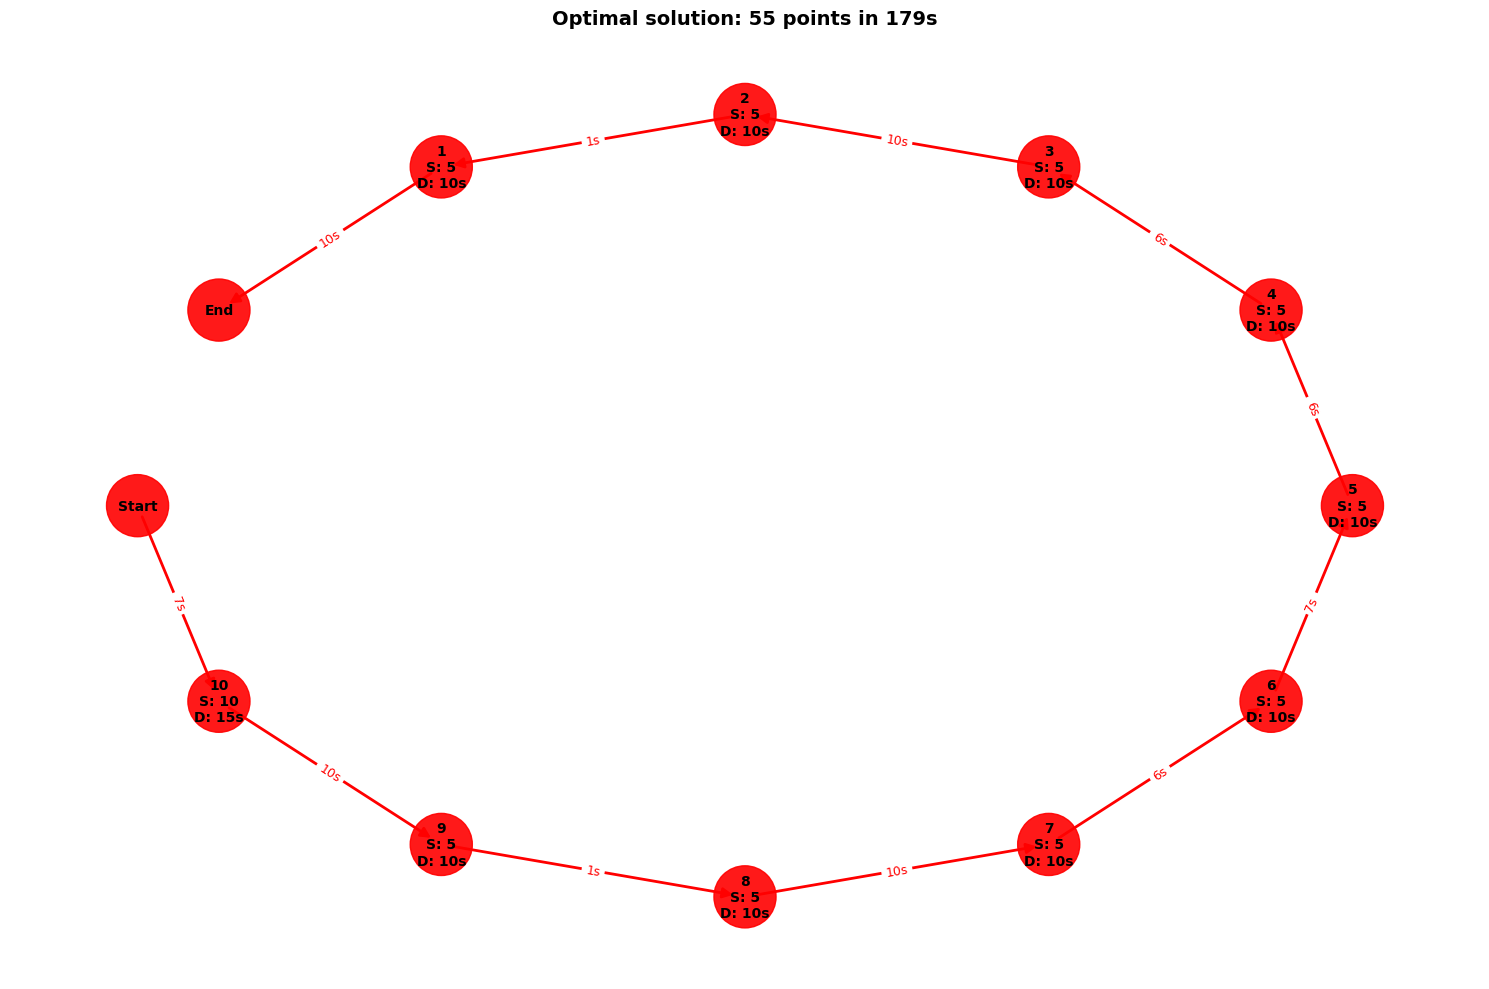

In [ ]:
from config_loader import CONFIG
from brains import MainBrain
from tasks import Task
from geometry import Point, OrientedPoint, OrientedPoint
import gc
from movement import TrajectoryParams, SpeedProfile
import random


if __name__ == "__main__":
    game_tasks = [
        Task(
            action_func=lambda: f"action {i}",
            start_func=lambda: print(f"action start {i}"),
            name=f"task{i}",
            execution_time=10,
            score=5,
            trajectory_params=TrajectoryParams(
                speed_profile=SpeedProfile(
                    **CONFIG.SPECIFIC_CONFIG["rolling_basis"]["speed_profiles"][
                        "default"
                    ]
                ),
                goal=OrientedPoint(random.randint(0, 300), random.randint(0, 200)),
                resolution=CONFIG.SPECIFIC_CONFIG["movement_manager"][
                    "movement_resolution"
                ],
            ),
        )
        for i in range(9)
    ]

    brain = MainBrain.get_dummy_brain(
        solve_planner_limit_sec=1
    )  # TODO: error is tasks are defined in params

    game_tasks.append(
        Task(
            action_func=lambda: "action 9",
            start_func=lambda: print("action start 9"),
            name="task9",
            execution_time=15,
            score=10,
            trajectory_params=TrajectoryParams(
                speed_profile=SpeedProfile(
                    **CONFIG.SPECIFIC_CONFIG["rolling_basis"]["speed_profiles"][
                        "default"
                    ]
                ),
                goal=brain.arena.zones[8],
                resolution=CONFIG.SPECIFIC_CONFIG["movement_manager"][
                    "movement_resolution"
                ],
            ),
        )
    )
    brain.game_tasks = game_tasks
    brain.get_game_tasks_planification(save_planification=True)
    brain.task_planner.visualize_solution(display_all_vertices=True)
    brain.task_planner.visualize_solution(display_all_edges=True)
    brain.task_planner.visualize_solution(
        display_all_edges=True, display_all_vertices=True
    )

    brain = MainBrain.get_dummy_brain(game_duration_sec=1000, solve_planner_limit_sec=1)
    brain.game_tasks = game_tasks
    brain.get_game_tasks_planification()
    brain.task_planner.visualize_solution()

On observe bien qu'il y a une erreur dans l'estimation des temps de déplacement ou que les param de la config sont erronés car le temp de déplacement demande beaucoup trop de temps.

19:43:20.715078 -> [StuffZone] [stuff_zone..:116]   DEBUG    | GoTo position request: Nearest go-to position to ally [POINT (150 100), theta: 0] is [POINT (17.5 40), theta: 3.141592653589793]
19:43:20.719324 -> [StuffZone] [stuff_zone..:116]   DEBUG    | GoTo position request: Nearest go-to position to ally [POINT (150 100), theta: 0] is [POINT (17.5 132.5), theta: 3.141592653589793]
19:43:20.722331 -> [StuffZone] [stuff_zone..:116]   DEBUG    | GoTo position request: Nearest go-to position to ally [POINT (150 100), theta: 0] is [POINT (77.5 35), theta: -1.5707963267948966]
19:43:20.728326 -> [StuffZone] [stuff_zone..:116]   DEBUG    | GoTo position request: Nearest go-to position to ally [POINT (150 100), theta: 0] is [POINT (82.5 162.5), theta: 1.5707963267948966]
19:43:20.731321 -> [StuffZone] [stuff_zone..:116]   DEBUG    | GoTo position request: Nearest go-to position to ally [POINT (150 100), theta: 0] is [POINT (110 105), theta: -1.5707963267948966]
19:43:20.736511 -> [StuffZone

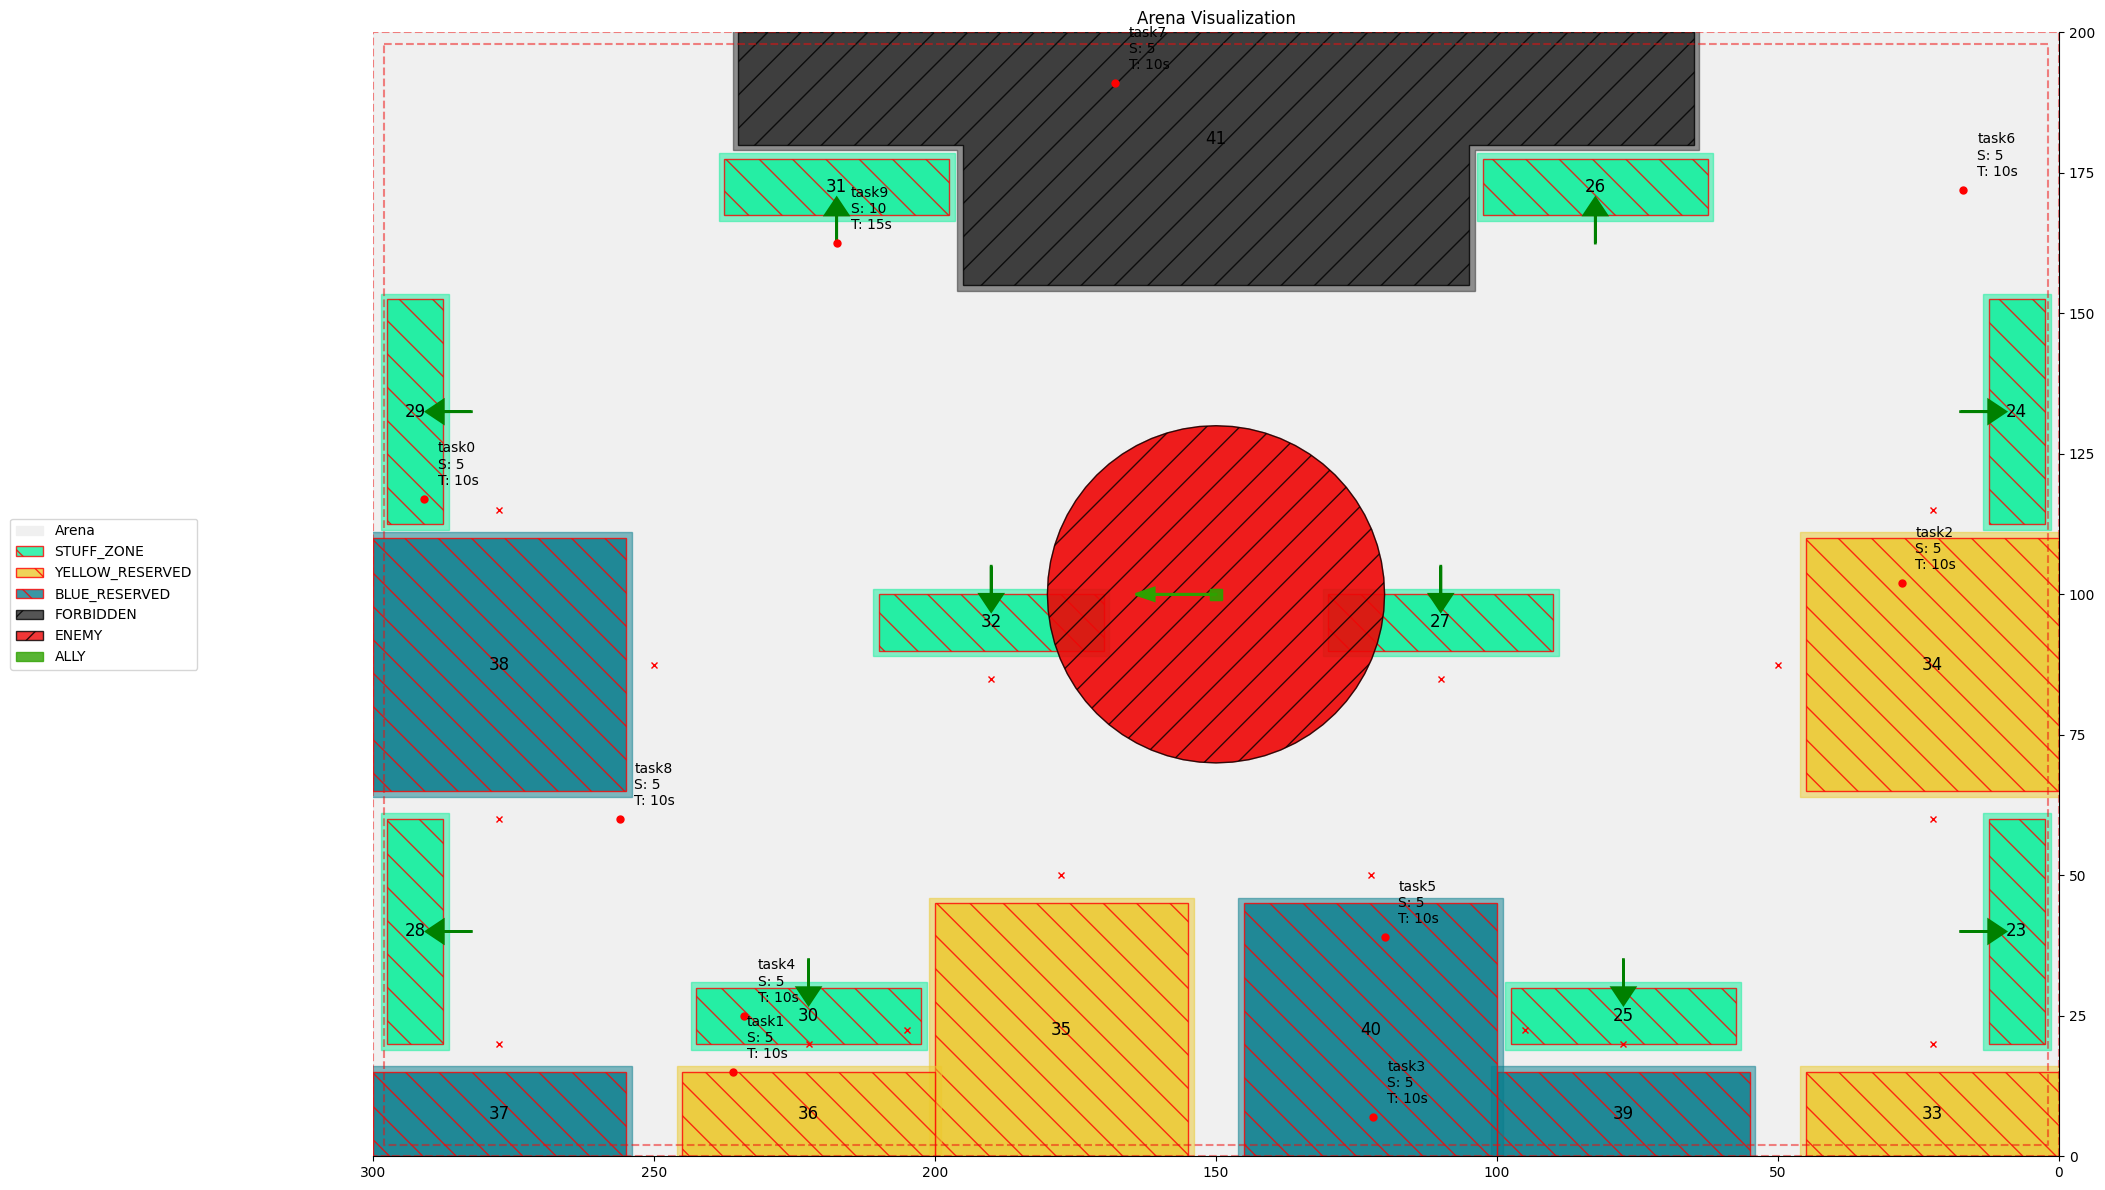

In [2]:
brain.visualize_tasks_in_arena()

Savergarder et charger une solution enregistrées

In [11]:
from tasks import TaskPlannerSolution, TaskPlanner

solution = TaskPlannerSolution.load_solution("task_planner_solution.json")
print(solution)

TaskPlannerSolution with score 45 and duration 90s


Un trajet irréalisable retourne un temps de trajet (je ne sais pas à quoi ce dernier fais réference) au lieu de +infini (int max)

In [11]:
brain.task_planner.travels_duration_matrix_sec

[[0, 37, 28, 20, 64, 36, 10, 28, 28, 55, 0, 0],
 [37, 0, 37, 28, 20, 64, 36, 10, 28, 28, 55, 65],
 [28, 37, 0, 28, 20, 64, 36, 10, 28, 28, 55, 36],
 [20, 28, 28, 0, 20, 64, 36, 10, 28, 28, 55, 28],
 [64, 20, 20, 20, 0, 64, 36, 10, 28, 28, 55, 45],
 [36, 64, 64, 64, 64, 0, 36, 10, 28, 28, 55, 55],
 [10, 36, 36, 36, 36, 36, 0, 10, 28, 28, 55, 44],
 [28, 10, 10, 10, 10, 10, 10, 0, 28, 28, 55, 29],
 [28, 28, 28, 28, 28, 28, 28, 28, 0, 28, 55, 64],
 [55, 28, 28, 28, 28, 28, 28, 28, 28, 0, 55, 31],
 [0, 55, 55, 55, 55, 55, 55, 55, 55, 55, 0, 0],
 [0, 65, 36, 28, 45, 55, 44, 29, 64, 31, 0, 0]]

# Actionneurs

In [1]:
from config_loader import CONFIG
from controllers.actuators_controller import ActuatorsController
from loggerplusplus import Logger
import time

actuator_manager = ActuatorsController(
    ser=12677020, logger=Logger(identifier="actuator_manager")
)

ModuleNotFoundError: No module named 'rolling_basis'

In [6]:
def demo_servo():
    actuator_manager.update_servo(pin=1, angle=90)
    time.sleep(1)
    actuator_manager.update_servo(pin=1, angle=0)
    time.sleep(1)
    actuator_manager.update_servo(pin=1, angle=90)
    time.sleep(1)
    actuator_manager.update_servo(pin=1, angle=0)


def demo_servo_detach():
    actuator_manager.update_servo(pin=1, angle=90, detach=True)
    time.sleep(1)
    actuator_manager.update_servo(pin=1, angle=0, detach=True)

In [11]:
demo_servo()

14:26:41.952318 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=90, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called
14:26:42.956426 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=0, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called
14:26:43.959025 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=90, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called
14:26:44.961769 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=0, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called


In [12]:
demo_servo_detach()

14:26:52.083142 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=90, min_angle=0, max_angle=180, detach=True, detach_delay=1000) called
14:26:53.086892 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=0, min_angle=0, max_angle=180, detach=True, detach_delay=1000) called
